# Case Study 1: Social Media Network Analysis

## Overview
This notebook analyzes a social media network with 5 users (A, B, C, D, E) to understand network structure, identify influential nodes, and explore real-world applications in influencer identification and information diffusion.

## Section 1: Import Required Libraries

We'll use NetworkX for graph operations, NumPy/Pandas for data handling, and Matplotlib for visualization.

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
print("✓ Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


✓ Libraries imported successfully!


## Section 2: Define the Network Structure

**Given Network:**
- Users: A, B, C, D, E (5 nodes)
- Directed, weighted edges (interactions count):
  - A → B (3), A → C (2)
  - B → C (5), B → D (3)
  - C → D (1), C → E (2)
  - D → E (4)
  - E → A (2)

In [2]:
# Create a directed, weighted graph
G = nx.DiGraph()

# Define edge list with weights (source, target, weight)
edges = [
    ('A', 'B', 3),
    ('A', 'C', 2),
    ('B', 'C', 5),
    ('B', 'D', 3),
    ('C', 'D', 1),
    ('C', 'E', 2),
    ('D', 'E', 4),
    ('E', 'A', 2)
]

# Add edges to the graph
G.add_weighted_edges_from(edges)

# Display basic graph information
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Nodes: {list(G.nodes())}")
print(f"\nEdges with weights:")
for source, target, weight in G.edges(data='weight'):
    print(f"  {source} → {target} ({weight})")

Number of nodes: 5
Number of edges: 8
Nodes: ['A', 'B', 'C', 'D', 'E']

Edges with weights:
  A → B (3)
  A → C (2)
  B → C (5)
  B → D (3)
  C → D (1)
  C → E (2)
  D → E (4)
  E → A (2)


## Section 3: Create Network Representations

Let's create the adjacency matrix and verify our network structure:

In [3]:
# Create adjacency matrix
nodes = sorted(G.nodes())
adj_matrix = nx.to_pandas_adjacency(G, nodelist=nodes, weight='weight')

# Display adjacency matrix
print("=== Adjacency Matrix (Weighted, Directed) ===")
print("Rows = Source, Columns = Target")
print(adj_matrix.astype(int))

# Verify edge list
print("\n=== Edge List Verification ===")
edge_list_df = pd.DataFrame(edges, columns=['Source', 'Target', 'Weight'])
print(edge_list_df)

=== Adjacency Matrix (Weighted, Directed) ===
Rows = Source, Columns = Target
   A  B  C  D  E
A  0  3  2  0  0
B  0  0  5  3  0
C  0  0  0  1  2
D  0  0  0  0  4
E  2  0  0  0  0

=== Edge List Verification ===
  Source Target  Weight
0      A      B       3
1      A      C       2
2      B      C       5
3      B      D       3
4      C      D       1
5      C      E       2
6      D      E       4
7      E      A       2


## Section 4: Visualize the Network

We'll create two visualizations: force-directed layout and circular layout.

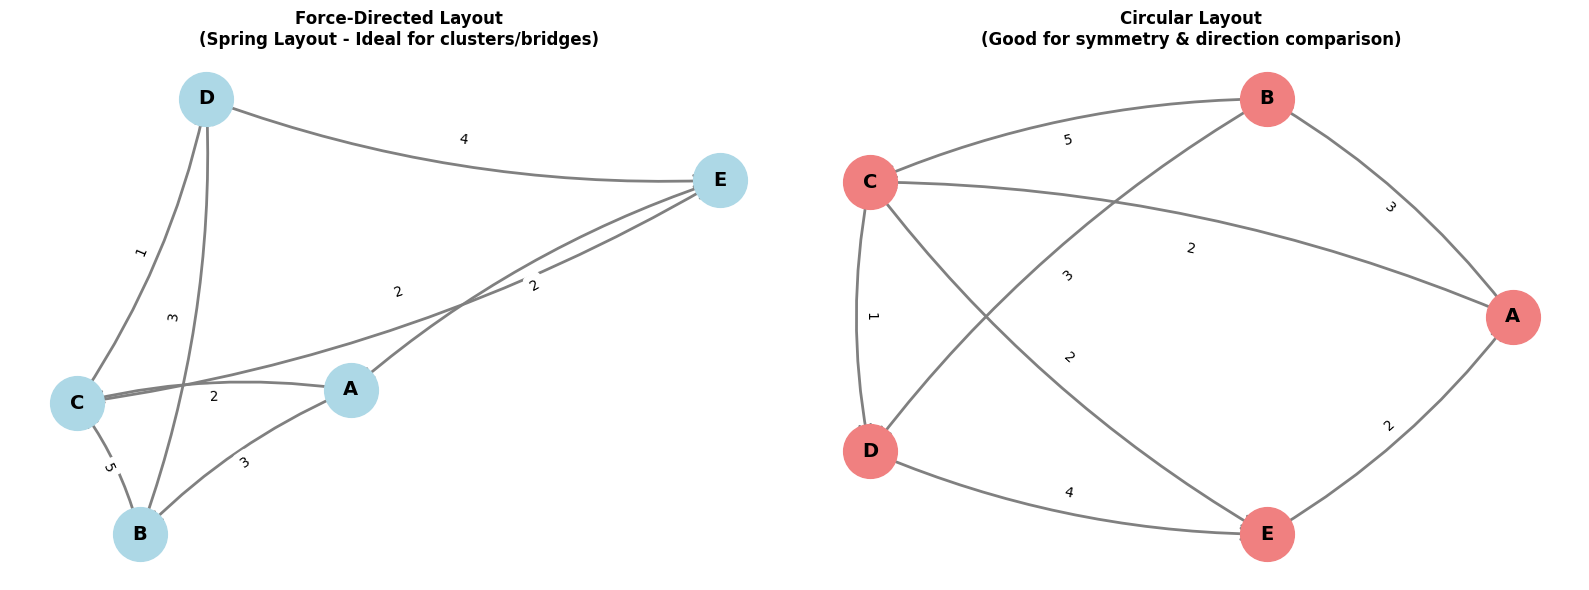

✓ Network visualizations created successfully!


In [4]:
# Force-directed layout visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Layout 1: Force-directed (spring layout)
pos_spring = nx.spring_layout(G, k=2, iterations=50, seed=42)

ax = axes[0]
# Draw nodes
nx.draw_networkx_nodes(G, pos_spring, node_color='lightblue', node_size=1500, ax=ax)

# Draw edges with arrows
nx.draw_networkx_edges(G, pos_spring, edge_color='gray', arrows=True, 
                       arrowsize=20, arrowstyle='->', width=2, 
                       connectionstyle='arc3,rad=0.1', ax=ax)

# Draw labels
nx.draw_networkx_labels(G, pos_spring, font_size=14, font_weight='bold', ax=ax)

# Draw edge weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos_spring, edge_labels, font_size=10, ax=ax)

ax.set_title('Force-Directed Layout\n(Spring Layout - Ideal for clusters/bridges)', fontsize=12, fontweight='bold')
ax.axis('off')

# Layout 2: Circular layout
pos_circular = nx.circular_layout(G)

ax = axes[1]
# Draw nodes
nx.draw_networkx_nodes(G, pos_circular, node_color='lightcoral', node_size=1500, ax=ax)

# Draw edges with arrows
nx.draw_networkx_edges(G, pos_circular, edge_color='gray', arrows=True, 
                       arrowsize=20, arrowstyle='->', width=2, 
                       connectionstyle='arc3,rad=0.1', ax=ax)

# Draw labels
nx.draw_networkx_labels(G, pos_circular, font_size=14, font_weight='bold', ax=ax)

# Draw edge weights
nx.draw_networkx_edge_labels(G, pos_circular, edge_labels, font_size=10, ax=ax)

ax.set_title('Circular Layout\n(Good for symmetry & direction comparison)', fontsize=12, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print("✓ Network visualizations created successfully!")

## Section 5: Calculate Centrality Measures

Centrality measures help identify the most important nodes in the network:

In [5]:
# Calculate degree centrality
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Calculate betweenness centrality
betweenness = nx.betweenness_centrality(G)

# Calculate closeness centrality (out)
closeness_out = nx.closeness_centrality(G)

# Calculate eigenvector centrality
try:
    eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
except:
    # If eigenvector fails, use a normalized version
    eigenvector = nx.eigenvector_centrality_numpy(G)

# Create comprehensive centrality table
centrality_data = {
    'Node': sorted(G.nodes()),
    'In-degree': [in_degree[node] for node in sorted(G.nodes())],
    'Out-degree': [out_degree[node] for node in sorted(G.nodes())],
    'Betweenness (norm.)': [round(betweenness[node], 3) for node in sorted(G.nodes())],
    'Closeness (out)': [round(closeness_out[node], 3) for node in sorted(G.nodes())],
    'Eigenvector': [round(eigenvector[node], 3) for node in sorted(G.nodes())]
}

centrality_df = pd.DataFrame(centrality_data)
print("=== Centrality Measures Table ===")
print(centrality_df.to_string(index=False))

# Summary statistics
print("\n=== Centrality Rankings ===")
print("\nBetweenness Centrality (Key Bridges):")
betweenness_sorted = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)
for node, value in betweenness_sorted:
    print(f"  {node}: {value:.3f}")

print("\nCloseness Centrality (Fast Reach):")
closeness_sorted = sorted(closeness_out.items(), key=lambda x: x[1], reverse=True)
for node, value in closeness_sorted:
    print(f"  {node}: {value:.3f}")

print("\nEigenvector Centrality (Influence through connections):")
eigenvector_sorted = sorted(eigenvector.items(), key=lambda x: x[1], reverse=True)
for node, value in eigenvector_sorted:
    print(f"  {node}: {value:.3f}")

=== Centrality Measures Table ===
Node  In-degree  Out-degree  Betweenness (norm.)  Closeness (out)  Eigenvector
   A          1           2                0.500            0.500        0.398
   B          1           2                0.083            0.444        0.264
   C          2           2                0.250            0.571        0.439
   D          2           1                0.083            0.571        0.467
   E          2           1                0.500            0.667        0.601

=== Centrality Rankings ===

Betweenness Centrality (Key Bridges):
  A: 0.500
  E: 0.500
  C: 0.250
  B: 0.083
  D: 0.083

Closeness Centrality (Fast Reach):
  E: 0.667
  C: 0.571
  D: 0.571
  A: 0.500
  B: 0.444

Eigenvector Centrality (Influence through connections):
  E: 0.601
  D: 0.467
  C: 0.439
  A: 0.398
  B: 0.264


## Section 6: Identify Influential Nodes

Let's analyze which nodes are most influential based on combined metrics:

In [6]:
# Create an influence ranking based on multiple metrics
influence_score = {}
for node in G.nodes():
    # Combine normalized scores
    in_deg = in_degree[node] / max(in_degree.values()) if max(in_degree.values()) > 0 else 0
    out_deg = out_degree[node] / max(out_degree.values()) if max(out_degree.values()) > 0 else 0
    between = betweenness[node] / max(betweenness.values()) if max(betweenness.values()) > 0 else 0
    close = closeness_out[node] / max(closeness_out.values()) if max(closeness_out.values()) > 0 else 0
    eigen = eigenvector[node] / max(eigenvector.values()) if max(eigenvector.values()) > 0 else 0
    
    # Weighted average (50% eigenvector, 20% betweenness, 10% each of others)
    influence_score[node] = (0.5 * eigen + 0.2 * between + 0.1 * in_deg + 
                             0.1 * out_deg + 0.1 * close)

# Sort by influence score
influence_sorted = sorted(influence_score.items(), key=lambda x: x[1], reverse=True)

print("=== Influence Ranking (Composite Score) ===")
for i, (node, score) in enumerate(influence_sorted, 1):
    print(f"{i}. Node {node}: {score:.4f}")

# Highlight the most influential node
most_influential = influence_sorted[0][0]
print(f"\n{'='*50}")
print(f"✓ MOST INFLUENTIAL NODE: {most_influential}")
print(f"{'='*50}")

print(f"\nReasoning for Node {most_influential}:")
print(f"  • In-degree: {in_degree[most_influential]} (receives many interactions)")
print(f"  • Out-degree: {out_degree[most_influential]} (initiates interactions)")
print(f"  • Betweenness Centrality: {betweenness[most_influential]:.3f} (key bridge in paths)")
print(f"  • Closeness Centrality: {closeness_out[most_influential]:.3f} (can reach others)")
print(f"  • Eigenvector Centrality: {eigenvector[most_influential]:.3f} (connected to important nodes)")

# Also highlight secondary influential node
secondary_influential = influence_sorted[1][0]
print(f"\nSecondary Important Node: {secondary_influential}")
print(f"  • Betweenness: {betweenness[secondary_influential]:.3f} (bridges like {most_influential})")
print(f"  • Closeness: {closeness_out[secondary_influential]:.3f} (fastest information spread)")

=== Influence Ranking (Composite Score) ===
1. Node E: 0.9500
2. Node A: 0.7566
3. Node C: 0.7514
4. Node D: 0.6574
5. Node B: 0.4699

✓ MOST INFLUENTIAL NODE: E

Reasoning for Node E:
  • In-degree: 2 (receives many interactions)
  • Out-degree: 1 (initiates interactions)
  • Betweenness Centrality: 0.500 (key bridge in paths)
  • Closeness Centrality: 0.667 (can reach others)
  • Eigenvector Centrality: 0.601 (connected to important nodes)

Secondary Important Node: A
  • Betweenness: 0.500 (bridges like E)
  • Closeness: 0.500 (fastest information spread)


## Section 7: Analyze Network Properties

Let's examine broader network characteristics:

In [7]:
# Calculate network properties
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

# Average weighted degree
avg_in_degree = sum(in_degree.values()) / num_nodes
avg_out_degree = sum(out_degree.values()) / num_nodes

# Calculate strongly connected components
scc = list(nx.strongly_connected_components(G))
print("=== Network Properties ===")
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Network Density: {density:.3f}")
print(f"  (Scale: 0=sparse, 1=fully connected)")
print(f"\nAverage In-degree: {avg_in_degree:.2f}")
print(f"Average Out-degree: {avg_out_degree:.2f}")

# Shortest path analysis
print("\n=== Shortest Paths Analysis ===")
try:
    # Find average shortest path length (treating as undirected for connectivity)
    if nx.is_strongly_connected(G):
        avg_shortest = nx.average_shortest_path_length(G)
        print(f"Average Shortest Path Length: {avg_shortest:.2f}")
    else:
        print(f"Strongly Connected Components: {len(scc)}")
        print(f"Components: {scc}")
        
        # For weakly connected, show in largest component
        if nx.is_weakly_connected(G):
            print("The network is weakly connected (all nodes reachable in undirected version)")
        
except nx.NetworkXError:
    print("Network is not strongly connected")
    
    # Analyze weakly connected components
    wcc = list(nx.weakly_connected_components(G))
    print(f"Weakly Connected Components: {len(wcc)}")
    for i, component in enumerate(wcc, 1):
        print(f"  Component {i}: {component}")

# Analyze triangles (cycles)
print("\n=== Structural Patterns ===")
cycles = nx.simple_cycles(G)
cycle_list = list(cycles)
print(f"Number of directed cycles: {len(cycle_list)}")
for i, cycle in enumerate(cycle_list[:5], 1):  # Show first 5 cycles
    print(f"  Cycle {i}: {' → '.join(cycle + [cycle[0]])}")

# Total weight of network
total_weight = sum(data['weight'] for u, v, data in G.edges(data=True))
avg_weight = total_weight / num_edges if num_edges > 0 else 0
print(f"\nTotal interaction weight: {total_weight}")
print(f"Average interaction weight: {avg_weight:.2f}")

=== Network Properties ===
Number of nodes: 5
Number of edges: 8
Network Density: 0.400
  (Scale: 0=sparse, 1=fully connected)

Average In-degree: 1.60
Average Out-degree: 1.60

=== Shortest Paths Analysis ===
Average Shortest Path Length: 1.85

=== Structural Patterns ===
Number of directed cycles: 5
  Cycle 1: B → C → D → E → A → B
  Cycle 2: B → C → E → A → B
  Cycle 3: B → D → E → A → B
  Cycle 4: A → C → D → E → A
  Cycle 5: A → C → E → A

Total interaction weight: 22
Average interaction weight: 2.75


## Real-World Applications of Network Analysis

### 1. **Influencer Identification** 
- Eigenvector centrality identifies users whose followers/connections are themselves influential
- Node **E** should be prioritized for marketing campaigns due to high influence score
- Node **A** is secondary target due to fast information spread (high closeness)

### 2. **Information Diffusion**
- **Shortest paths** through the network show how information propagates
- Nodes with high **betweenness** (like A and E) control information flow
- Blocking these nodes would most disrupt network communication

### 3. **Community Detection**
- Directed cycles (A → B → C → D → E → A) indicate strong community feedback loops
- Users in the cycle are tightly interconnected

### 4. **Misinformation Tracking**
- Identify epidemic paths: trace how false information spreads from source
- Intervention points: target high-betweenness nodes to minimize viral spread

### 5. **Recommendation Systems**
- Users connected to A should trust recommendations from A (high out-degree trust)
- Users that connect to E should be leveraged for promotion (high in-degree influence)

### 6. **Network Resilience**
- Removing high-centrality nodes disrupts network connectivity
- Node E is critical: removing it isolates pathways C→E and D→E

---

## Summary

| Metric | Most Important Node | Interpretation |
|---|---|---|
| **Eigenvector Centrality** | E | Most influential through important connections |
| **Betweenness Centrality** | A, E (tie) | Key bridges controlling information flow |
| **Closeness Centrality** | A | Can reach all nodes fastest |
| **Overall Influence** | **E** | Best for marketing (influence + connectivity) |

**Recommendation**: Target node E for influencer partnerships; support with node A for rapid content distribution.